In [87]:
# Logistic Regression for Heart Disease Prediction data from Kaggle

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import plotly.express as px

In [88]:
import pandas as pd

# Fetch the dataset
# After uploading 'framingham.csv' to your Colab environment, update the path below.
# For example, if uploaded directly to the session, it might be '/content/framingham.csv'
df = pd.read_csv("/framingham.csv")

# printing first 5 rows
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0


In [89]:
# education column seems irrelevant so dropping it from data
#df.drop("education",axis=1, inplace=True)
if "education" in df.columns:
    # Drop the "education" column
    df.drop("education", axis=1, inplace=True)
    print("Education column dropped successfully.")
else:
    print("Education column not found in the DataFrame.")

df.head()
df.shape

Education column dropped successfully.


(4238, 15)

In [90]:
df.corr()

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
male,1.000000,-0.028979,0.197596,0.317930,-0.052506,-0.004546,0.005313,0.015708,-0.070322,-0.035989,0.057933,0.081672,-0.116620,0.006083,0.088428
age,-0.028979,1.000000,-0.213748,-0.192791,0.122995,0.057655,0.307194,0.101258,0.262131,0.394302,0.206104,0.135800,-0.012823,0.122256,0.225256
currentSmoker,0.197596,-0.213748,1.000000,0.769690,-0.048938,-0.032988,-0.103260,-0.044295,-0.046562,-0.130230,-0.107746,-0.167650,0.062356,-0.056826,0.019456
cigsPerDay,0.317930,-0.192791,0.769690,1.000000,-0.046134,-0.032707,-0.066146,-0.037067,-0.026320,-0.088780,-0.056632,-0.092856,0.075157,-0.058960,0.057884
BPMeds,-0.052506,0.122995,-0.048938,-0.046134,1.000000,0.117365,0.261187,0.052047,0.080558,0.254219,0.194227,0.100668,0.015233,0.051176,0.087489
prevalentStroke,-0.004546,0.057655,-0.032988,-0.032707,0.117365,1.000000,0.074830,0.006949,0.000067,0.057009,0.045190,0.025891,-0.017676,0.018431,0.061810
prevalentHyp,0.005313,0.307194,-0.103260,-0.066146,0.261187,0.074830,1.000000,0.077808,0.163993,0.696755,0.615751,0.301318,0.147261,0.086834,0.177603
diabetes,0.015708,0.101258,-0.044295,-0.037067,0.052047,0.006949,0.077808,1.000000,0.040278,0.111283,0.050329,0.087036,0.048994,0.617627,0.097317
totChol,-0.070322,0.262131,-0.046562,-0.026320,0.080558,0.000067,0.163993,0.040278,1.000000,0.208908,0.165182,0.115767,0.091125,0.046408,0.082184
sysBP,-0.035989,0.394302,-0.130230,-0.088780,0.254219,0.057009,0.696755,0.111283,0.208908,1.000000,0.784002,0.326981,0.182246,0.140621,0.216429


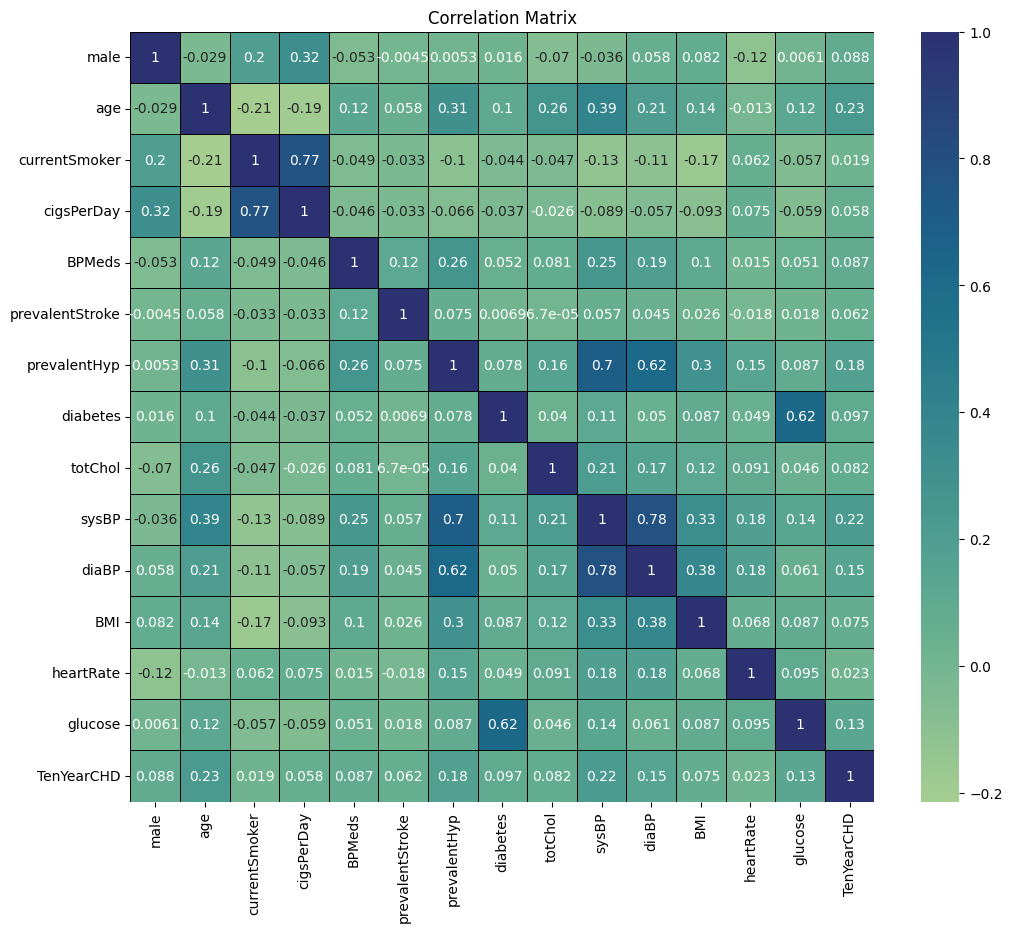

In [91]:
# colored correlation matrix
plt.figure(figsize=(12,10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='crest', linewidth = 0.5, linecolor="black")
plt.title('Correlation Matrix')
plt.show()

In [92]:
# checking for null values

print("Checking for missing values")
df.isna().sum()

Checking for missing values


,0
male,0
age,0
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50
sysBP,0


In [93]:
# filling missing values
df.fillna({'cigsPerDay': 0}, inplace=True)
df.fillna({'BMI': df['BMI'].median()}, inplace=True)
df.fillna({'BPMeds': df['BPMeds'].median()},  inplace=True)
df.fillna({'totChol': df['totChol'].median()},  inplace=True)
df.fillna({'heartRate': df['heartRate'].median()},  inplace=True)
df.fillna({'glucose': df['glucose'].median()},  inplace=True)
df.isna().sum()

,0
male,0
age,0
currentSmoker,0
cigsPerDay,0
BPMeds,0
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,0
sysBP,0


array([[<Axes: title={'center': 'male'}>,
        <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'currentSmoker'}>,
        <Axes: title={'center': 'cigsPerDay'}>],
       [<Axes: title={'center': 'BPMeds'}>,
        <Axes: title={'center': 'prevalentStroke'}>,
        <Axes: title={'center': 'prevalentHyp'}>,
        <Axes: title={'center': 'diabetes'}>],
       [<Axes: title={'center': 'totChol'}>,
        <Axes: title={'center': 'sysBP'}>,
        <Axes: title={'center': 'diaBP'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'heartRate'}>,
        <Axes: title={'center': 'glucose'}>,
        <Axes: title={'center': 'TenYearCHD'}>, <Axes: >]], dtype=object)

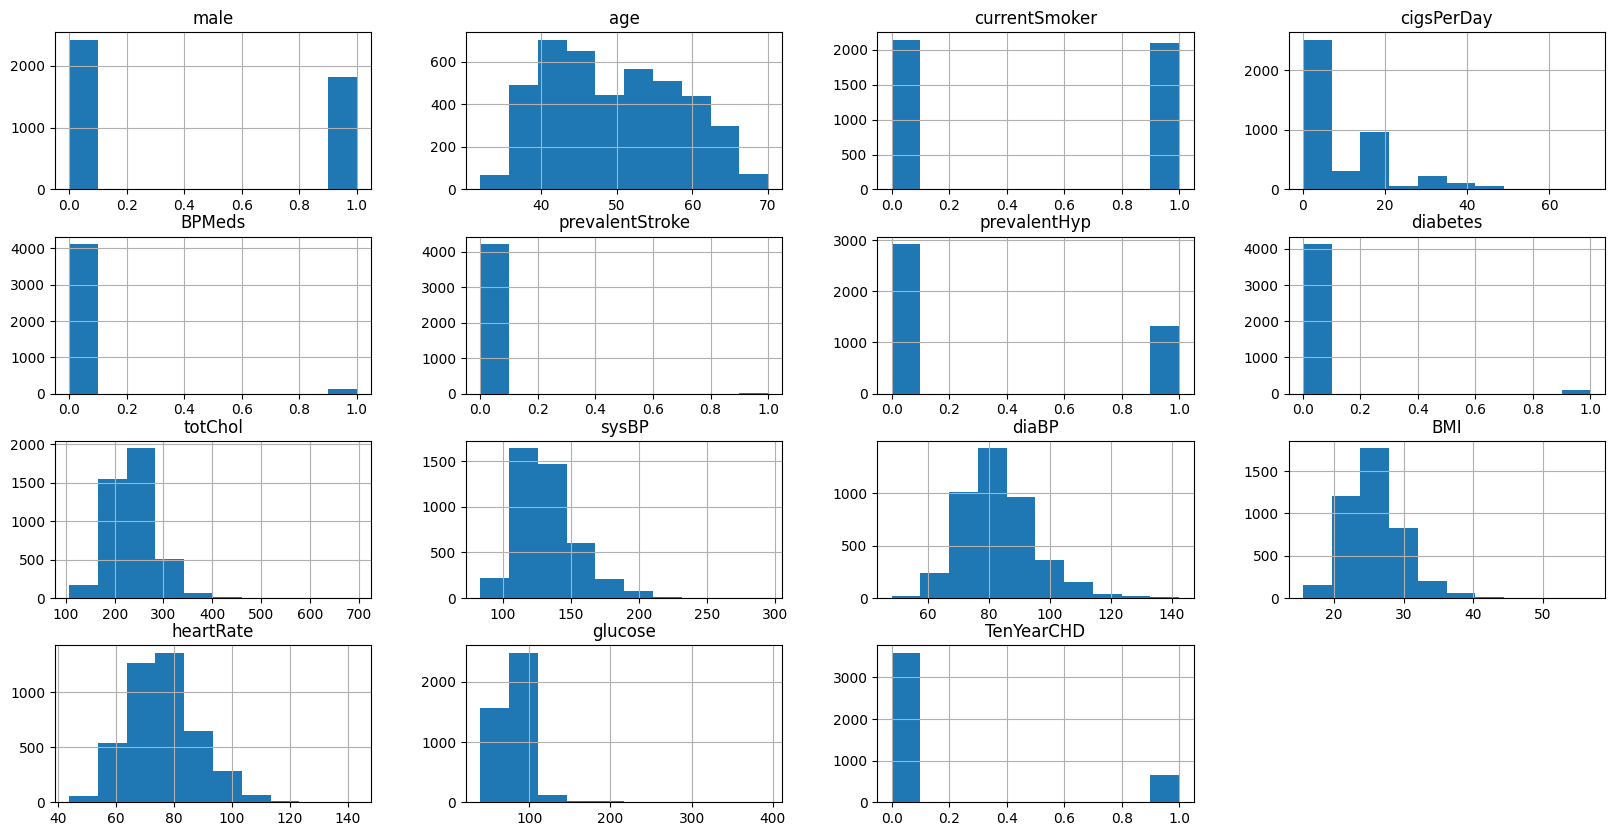

In [94]:
df.hist(figsize=(20,10))

In [95]:
X=df.drop("TenYearCHD",axis=1)
X.head()

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0


In [96]:
y=df["TenYearCHD"].values.ravel()
# ravel converts y from 2d to 1d array
y

array([0, 0, 0, ..., 0, 0, 0])

In [97]:
#Standard Scaler for Data
scaler = StandardScaler(copy=True, with_mean=True, with_std=True)
X = scaler.fit_transform(X)
X

array([[ 1.1531919 , -1.23495068, -0.98827076, ...,  0.28737925,
         0.34276147, -0.2013593 ],
       [-0.86715836, -0.41825733, -0.98827076, ...,  0.7197521 ,
         1.59029076, -0.24509896],
       [ 1.1531919 , -0.18491638,  1.01186844, ..., -0.11305697,
        -0.07308163, -0.5075369 ],
       ...,
       [-0.86715836, -0.18491638,  1.01186844, ..., -0.93358273,
         0.67543595,  0.19229761],
       [-0.86715836, -0.65159829,  1.01186844, ..., -1.63127529,
         0.84177318, -0.15761964],
       [-0.86715836,  0.28176554, -0.98827076, ..., -1.06378592,
         0.34276147,  1.11083042]])

In [98]:
# splitting dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [99]:
# Initialize the LogisticRegression model
para=[{'max_iter':[1000,2000,3000]}]

# gridsearchcv is a technique to search through the best parameter values
#from the given set of the grid of parameters. It is basically a cross-validation method
# so it will see how many max iterations are required for logistic regression
regressor = GridSearchCV(estimator=LogisticRegression(), param_grid=para, cv=5)

# Train the model
regressor.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid=[{'max_iter': [1000, 2000, 3000]}])

In [100]:
print('Logistic Regressor Training Score is : ' ,  regressor.score(X_train, y_train)*100)
print('Logistic Regressor Test Score is : ' , regressor.score(X_test, y_test)*100)

Logistic Regressor Training Score is :  85.2765058119056
Logistic Regressor Test Score is :  86.27591136526091


In [101]:
y_pred_test = regressor.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_test)
conf_matrix = confusion_matrix(y_test, y_pred_test)
class_report = classification_report(y_test, y_pred_test)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

Accuracy: 0.862759113652609
Confusion Matrix:
 [[1185    9]
 [ 183   22]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.99      0.93      1194
           1       0.71      0.11      0.19       205

    accuracy                           0.86      1399
   macro avg       0.79      0.55      0.56      1399
weighted avg       0.84      0.86      0.82      1399



Text(0.5, 1.0, 'Score of LOGISTIC MODEL')

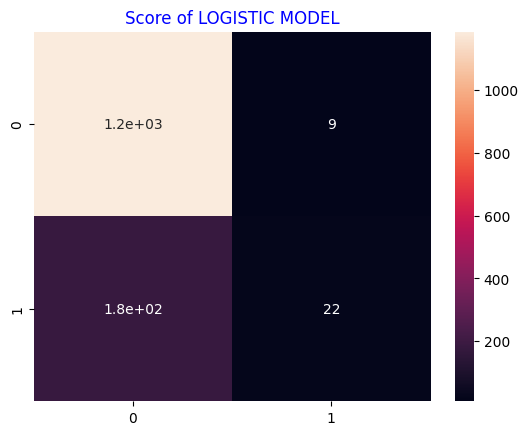

In [102]:
CM = confusion_matrix(y_test,y_pred_test)
sns.heatmap(CM, annot =True)
plt.title("Score of LOGISTIC MODEL", color = 'Blue', loc = 'Center')

In [103]:
# groupby() method to count the number of occurrences of each unique value in the TenYearCHD column

fig = px.pie(df, values=df.groupby('TenYearCHD').size(),
           names=["1","0"],title="<b>Patient with Heart Disease in 10 yrs",
           hole=.6,
       color_discrete_sequence=px.colors.qualitative.Pastel,template="plotly")
fig.update_layout(title_font_size=30)
fig.show()

In [104]:
zero = df['TenYearCHD'].value_counts()[0]
one = df['TenYearCHD'].value_counts()[1]

print("Total 0's in TenYearCHD column are: ", zero)
print("Total 1's in TenYearCHD column are: ", one)

Total 0's in TenYearCHD column are:  3594
Total 1's in TenYearCHD column are:  644


In [105]:
#df.replace({'male': {0: 'Female', 1: 'Male'}}, inplace=True)